# Question-  D

===== hc3 Summary =====
                            OLS Regression Results                            
Dep. Variable:               Strength   R-squared:                       0.971
Model:                            OLS   Adj. R-squared:                  0.965
Method:                 Least Squares   F-statistic:                     165.4
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           1.02e-11
Time:                        23:02:20   Log-Likelihood:                -42.759
No. Observations:                  19   AIC:                             93.52
Df Residuals:                      15   BIC:                             97.30
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         44.9756      0

/var/folders/l9/_79zbgm11xx430g_pbmkcdk80000gn/T/ipykernel_81272/4203431162.py:9: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  hc = pd.read_csv("HardwoodTensileStr.txt", delim_whitespace=True)
/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=19
  res = hypotest_fun_out(*samples, **kwds)


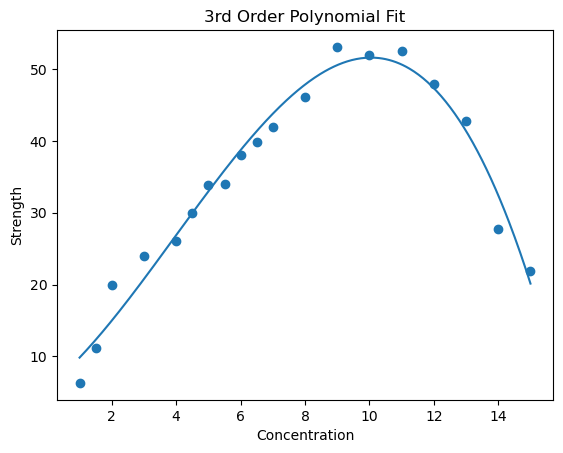

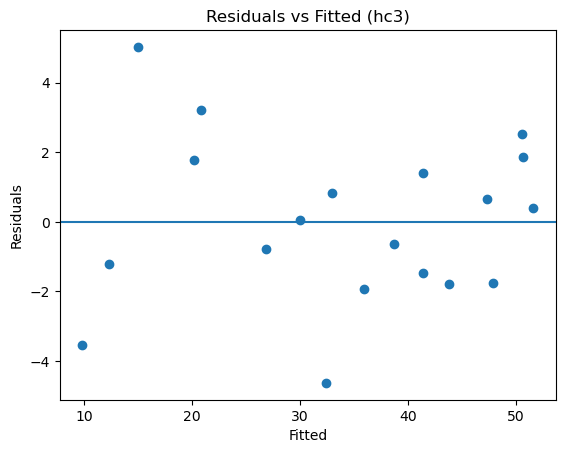

===== hc5 Summary =====
                            OLS Regression Results                            
Dep. Variable:               Strength   R-squared:                       0.989
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     233.1
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           3.02e-12
Time:                        23:02:20   Log-Likelihood:                -33.467
No. Observations:                  19   AIC:                             78.93
Df Residuals:                      13   BIC:                             84.60
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         43.6188      0

/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=19
  res = hypotest_fun_out(*samples, **kwds)
/opt/anaconda3/lib/python3.12/site-packages/scipy/stats/_axis_nan_policy.py:531: UserWarning: kurtosistest only valid for n>=20 ... continuing anyway, n=19
  res = hypotest_fun_out(*samples, **kwds)


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# --------------------
# Load Data
# --------------------
hc = pd.read_csv("HardwoodTensileStr.txt", delim_whitespace=True)

x_raw = hc["Concentration"]
x = x_raw - x_raw.mean()      # centered predictor
y = hc["Strength"]

# --------------------
# Helper function
# --------------------
def fit_model(X, y):
    X = sm.add_constant(X)
    model = sm.OLS(y, X).fit()
    return model

# --------------------
# (i) Third-order polynomial
# --------------------
X3 = pd.DataFrame({
    "x": x,
    "x2": x**2,
    "x3": x**3
})

hc3 = fit_model(X3, y)
print("===== hc3 Summary =====")
print(hc3.summary())

# --------------------
# (ii) Scatter + fitted curve (hc3)
# --------------------
plt.figure()
plt.scatter(x_raw, y)
grid = np.linspace(x_raw.min(), x_raw.max(), 400)
xg = grid - x_raw.mean()
Xg3 = sm.add_constant(pd.DataFrame({
    "x": xg,
    "x2": xg**2,
    "x3": xg**3
}))
plt.plot(grid, hc3.predict(Xg3))
plt.xlabel("Concentration")
plt.ylabel("Strength")
plt.title("3rd Order Polynomial Fit")
plt.show()

# Residual plot
plt.figure()
plt.scatter(hc3.fittedvalues, hc3.resid)
plt.axhline(0)
plt.xlabel("Fitted")
plt.ylabel("Residuals")
plt.title("Residuals vs Fitted (hc3)")
plt.show()

# --------------------
# (iii) Fifth-order polynomial
# --------------------
X5 = pd.DataFrame({
    "x": x,
    "x2": x**2,
    "x3": x**3,
    "x4": x**4,
    "x5": x**5
})

hc5 = fit_model(X5, y)
print("===== hc5 Summary =====")
print(hc5.summary())

# --------------------
# (iv) Drop largest p-value term (excluding intercept)
# --------------------
pvals = hc5.pvalues.drop("const")
drop_term = pvals.idxmax()
print("Term with largest p-value:", drop_term)

X_final = X5.drop(columns=[drop_term])
hc_final = fit_model(X_final, y)

print("===== Final Model Summary =====")
print(hc_final.summary())

# Question E


=== Model selection table (degrees 1..8) ===
 degree        AIC        BIC   Adj_R2     F_pvalue
      1 237.589881 240.181555 0.852206 4.335960e-12
      2 228.074398 231.961909 0.899501 4.062308e-13
      3 229.844345 235.027693 0.896022 4.569671e-12
      4 231.460444 237.939629 0.892830 3.751772e-11
      5 233.243382 241.018403 0.888626 2.771264e-10
      6 235.681128 242.160312 0.874697 2.062094e-10
      7 239.266315 245.745499 0.856903 8.749079e-10
      8 248.108015 254.587199 0.801460 3.053749e-08

Best degree by AIC: 2
Best degree by BIC: 2

=== Chosen model (degree = 2) summary ===
                            OLS Regression Results                            
Dep. Variable:                      y   R-squared:                       0.907
Model:                            OLS   Adj. R-squared:                  0.900
Method:                 Least Squares   F-statistic:                     117.4
Date:                Sun, 22 Feb 2026   Prob (F-statistic):           4.06e-13
Tim

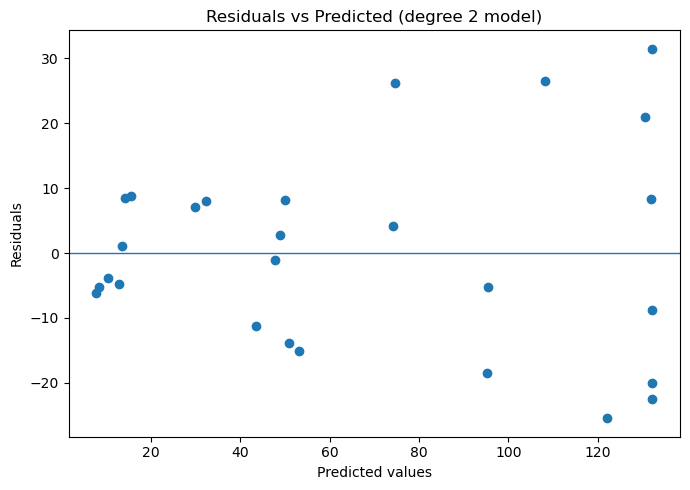


=== Part (4): Prediction at x = 110 (95% PI) ===
     mean  obs_ci_lower  obs_ci_upper
51.499206      18.17506     84.823352

Predicted age at diameter 110: 51.499
95% prediction interval: (18.175, 84.823)


In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.api as sm

# ============================================================
# Problem E: TreeAgeDiamSugarMaple.txt
# x = tree diameter, y = tree age
# ============================================================

# ---------- Load data (file has a header like "Diamet Age") ----------
df = pd.read_csv("TreeAgeDiamSugarMaple.txt", sep=r"\s+", engine="python")
df.columns = [c.strip() for c in df.columns]  # clean column names

# Rename first two columns to x and y (robust even if names differ)
df = df.rename(columns={df.columns[0]: "x", df.columns[1]: "y"})

# Convert to numeric (will raise error if anything non-numeric remains)
df["x"] = pd.to_numeric(df["x"], errors="raise")
df["y"] = pd.to_numeric(df["y"], errors="raise")

x = df["x"].to_numpy(dtype=float)
y = df["y"].to_numpy(dtype=float)

# ---------- Helper: fit polynomial of degree d ----------
# Model: y = b0 + b1*x + b2*x^2 + ... + bd*x^d + error
def fit_poly_degree(x, y, d):
    X = np.column_stack([x**k for k in range(1, d + 1)])
    X = sm.add_constant(X)  # intercept
    return sm.OLS(y, X).fit()

# ============================================================
# (1) Fit degrees 1..8 and choose best by AIC/BIC
# ============================================================
models = {d: fit_poly_degree(x, y, d) for d in range(1, 9)}

rows = []
for d, m in models.items():
    rows.append({
        "degree": d,
        "AIC": m.aic,
        "BIC": m.bic,
        "Adj_R2": m.rsquared_adj,
        "F_pvalue": m.f_pvalue
    })

table = pd.DataFrame(rows).sort_values("degree").reset_index(drop=True)
print("\n=== Model selection table (degrees 1..8) ===")
print(table.to_string(index=False))

best_aic_deg = int(table.loc[table["AIC"].idxmin(), "degree"])
best_bic_deg = int(table.loc[table["BIC"].idxmin(), "degree"])
print(f"\nBest degree by AIC: {best_aic_deg}")
print(f"Best degree by BIC: {best_bic_deg}")

# Choose the model (use BIC by default; you can switch to AIC if instructed)
best_deg = best_bic_deg
best_model = models[best_deg]

print(f"\n=== Chosen model (degree = {best_deg}) summary ===")
print(best_model.summary())

# ============================================================
# (2) Degree-2 model: test H0: coefficient of x^2 = 0 at alpha=0.05
# ============================================================
m2 = models[2]
pval_x2 = float(m2.pvalues[2])  # index: 0=const, 1=x, 2=x^2

print("\n=== Part (2): Test for x^2 in degree-2 model ===")
print(f"p-value for x^2 term = {pval_x2:.6g}")

alpha = 0.05
if pval_x2 < alpha:
    print(f"Decision at alpha={alpha}: Reject H0 (x^2 is significant).")
else:
    print(f"Decision at alpha={alpha}: Fail to reject H0 (x^2 is not significant).")

# ============================================================
# (3) Residuals vs predicted for the chosen model
# ============================================================
fitted = best_model.fittedvalues
resid = best_model.resid

plt.figure(figsize=(7, 5))
plt.scatter(fitted, resid)
plt.axhline(0, linewidth=1)
plt.xlabel("Predicted values")
plt.ylabel("Residuals")
plt.title(f"Residuals vs Predicted (degree {best_deg} model)")
plt.tight_layout()
plt.show()

# ============================================================
# (4) 95% prediction interval for age at x = 110
# ============================================================
x0 = 110.0
X0 = np.array([[1] + [x0**k for k in range(1, best_deg + 1)]], dtype=float)

pred = best_model.get_prediction(X0).summary_frame(alpha=0.05)

print("\n=== Part (4): Prediction at x = 110 (95% PI) ===")
print(pred[["mean", "obs_ci_lower", "obs_ci_upper"]].to_string(index=False))

mean = float(pred["mean"].iloc[0])
lo = float(pred["obs_ci_lower"].iloc[0])
hi = float(pred["obs_ci_upper"].iloc[0])

print(f"\nPredicted age at diameter 110: {mean:.3f}")
print(f"95% prediction interval: ({lo:.3f}, {hi:.3f})")